<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionales2026/blob/main/Semana12/AjusteNolineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
# Vamos a cargar datos
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [110]:
import os
os.chdir("/content/drive/MyDrive/ColabNotebooks/Cursos/MetodosComputacionales2026")

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize as spo
from scipy.optimize import curve_fit

Data = pd.read_csv('Semana12/Data/Sigmoid_con_ruido.csv')

In [112]:
x = Data["x"].values
y = Data["y_ruido"].values
sigma0 = np.std( Data['error'].values, ddof = 1 )
sigma = np.full_like(y, sigma0)

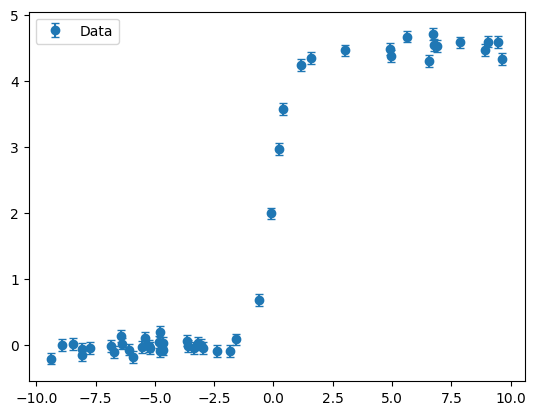

In [113]:
plt.errorbar(x,y, yerr=sigma, fmt='o', capsize=3,label='Data')
plt.legend()

In [114]:
# Definir el modelo
def sigmoide(x,p):
  A,B,C,D = p
  return A/(B+np.exp(-C*x)) + D

In [115]:
p0 = np.array([5.,2.,1.,3])
_x = np.linspace(min(x),max(x),100)
_y = sigmoide(_x,p0)

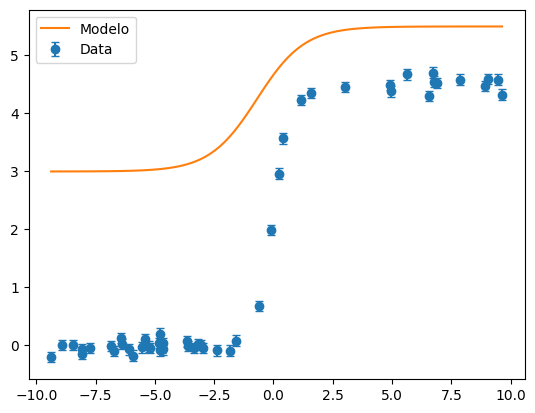

In [116]:
plt.errorbar(x,y, yerr=sigma, fmt='o', capsize=3,label='Data')
plt.plot(_x,_y,label='Modelo')
plt.legend()

In [117]:
def chi2_con_error(p,x,y,sigma,modelo):
  return np.sum(  (y-modelo(x,p))**2 / sigma**2  )

In [118]:
chi2_con_error(p0,x,y,sigma,sigmoide)

np.float64(42688.21811579728)

In [119]:
# usamos optimze
p0 = np.array([5.,2.,1.,3.])
result = spo.minimize(chi2_con_error,p0,args=(x,y,sigma,sigmoide),method='Nelder-Mead')
result

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 57.65808526473979
             x: [ 4.693e+00  1.038e+00  2.874e+00 -2.233e-02]
           nit: 197
          nfev: 334
 final_simplex: (array([[ 4.693e+00,  1.038e+00,  2.874e+00, -2.233e-02],
                       [ 4.693e+00,  1.038e+00,  2.874e+00, -2.233e-02],
                       ...,
                       [ 4.693e+00,  1.038e+00,  2.874e+00, -2.233e-02],
                       [ 4.693e+00,  1.038e+00,  2.874e+00, -2.233e-02]]), array([ 5.766e+01,  5.766e+01,  5.766e+01,  5.766e+01,
                        5.766e+01]))

In [120]:
paramopt = result.x
paramopt

array([ 4.69276615,  1.03801403,  2.87381   , -0.02232999])

In [121]:
_x = np.linspace(min(x),max(x),100)
_y = sigmoide(_x,paramopt)

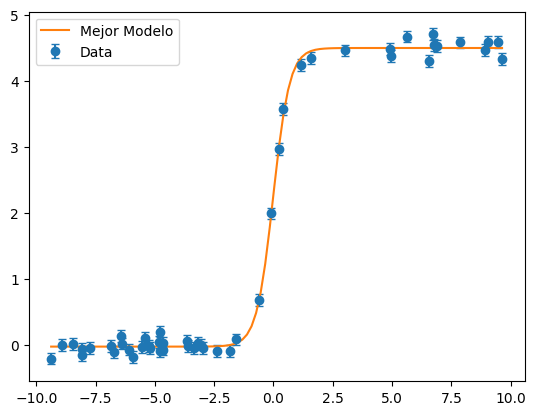

In [122]:
plt.errorbar(x,y, yerr=sigma, fmt='o', capsize=3,label='Data')
plt.plot(_x,_y,label='Mejor Modelo')
plt.legend()

In [170]:
# Ajustamos con curvefit - modificamos el modelo para el paquete
def sigmoide(x, A, B, C, D):
    return A / (B + np.exp(-C*x)) + D

In [171]:
p0 = np.array([1.,1.,1.,0.5])
p_cf, pcov_cf = curve_fit(
    sigmoide,
    x,
    y,
    p0=p0,
    sigma=sigma,
    absolute_sigma=True,
    maxfev=10000
)

In [172]:
# Miremos la chi2 reducida
chi2_cf = np.sum(((y - sigmoide(x, *p_cf)) / sigma)**2)
chi2_cf

np.float64(57.65808518525406)

In [173]:
N = len(x)
# Miramos el numero de parametros en el modelo
npar = len(p_cf)
ndof = N - npar


# Miremos la chi2 reducida, buen ajuste cerca a 1
chi2red_cf = chi2_cf / ndof
chi2red_cf

np.float64(1.2534366344620447)

In [174]:
# Matriz de covarianza
pcov_cf

array([[ 0.0613989 ,  0.01354605, -0.00721426, -0.00101173],
       [ 0.01354605,  0.0030325 , -0.00135031, -0.00016229],
       [-0.00721426, -0.00135031,  0.025516  ,  0.00035698],
       [-0.00101173, -0.00016229,  0.00035698,  0.00026222]])

In [175]:
# Miremos el error en los parametros
# INCERTIDUMBRES DEL AJUSTE curve_fit
perr_cf = np.sqrt(np.diag(pcov_cf))
perr_cf

array([0.24778802, 0.05506813, 0.15973728, 0.01619329])

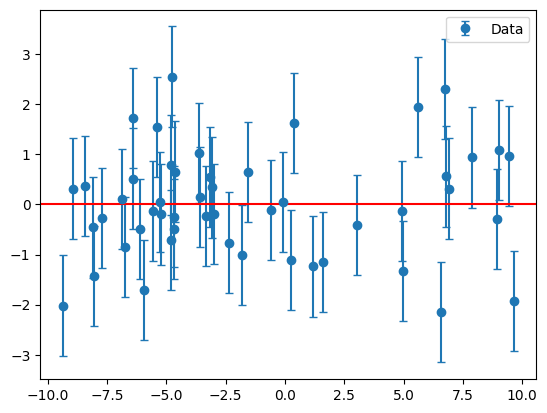

In [176]:
# pintemos los residuales
residuales = ( y - sigmoide(x, *p_cf) ) / sigma

plt.errorbar(x,residuales, yerr=np.ones_like(residuales), fmt='o', capsize=3,label='Data')
plt.axhline(y=0, color='r', linestyle='-')
plt.legend()

t observados:
[18.93866561 18.84967274 17.99064009 -1.37878075]
t critico = 2.0128955989194286
p-values:
[0.         0.         0.         0.17463063]

Resumen:
  parametro  estimado  error_std  t_observado  abs_t_observado   p_value
0         A  4.692774   0.247788    18.938666        18.938666  0.000000
1         B  1.038016   0.055068    18.849673        18.849673  0.000000
2         C  2.873776   0.159737    17.990640        17.990640  0.000000
3         D -0.022327   0.016193    -1.378781         1.378781  0.174631


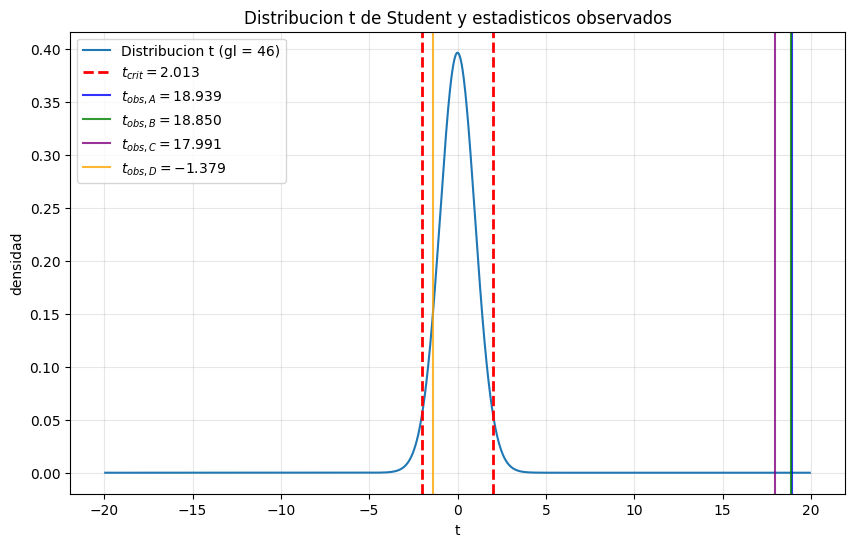

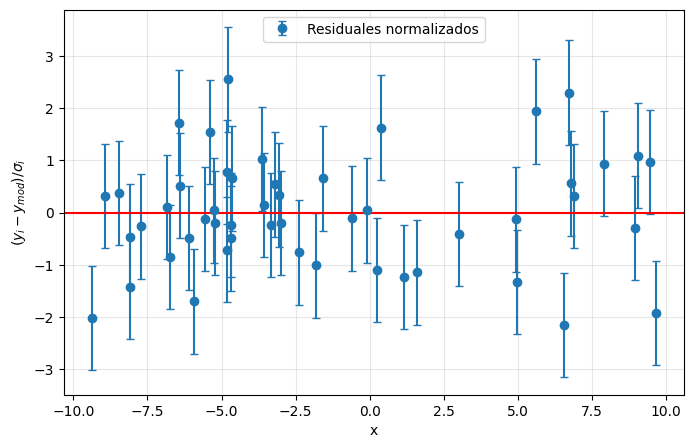

In [177]:
# ============================================================
# ESTADISTICO t DE CADA PARAMETRO
# ============================================================
from scipy.stats import t

# H0: parametro = 0
# t_obs = estimado / error_estandar

t_stats = p_cf / perr_cf
print("t observados:")
print(t_stats)

# valor critico bilateral para 95% de confianza
alpha = 0.05
t_crit = t.ppf(1 - alpha/2, df=ndof)
print("t critico =", t_crit)

# p-values bilaterales
p_values = 2 * (1 - t.cdf(np.abs(t_stats), df=ndof))
print("p-values:")
print(p_values)

# Resumen de parametros, errores y estadisticos t
param_names = ['A', 'B', 'C', 'D']
resumen_t = pd.DataFrame({
    'parametro': param_names,
    'estimado': p_cf,
    'error_std': perr_cf,
    't_observado': t_stats,
    'abs_t_observado': np.abs(t_stats),
    'p_value': p_values
})

print("\nResumen:")
print(resumen_t)

# ============================================================
# GRAFICA DE LA DISTRIBUCION t DE STUDENT
# ============================================================
# Dibujamos la distribucion t con los grados de libertad correctos
# y marcamos el valor critico en rojo y los valores observados en negro.

tmax = max(6, np.max(np.abs(t_stats)) + 1)
t_grid = np.linspace(-tmax, tmax, 2000)
pdf_t = t.pdf(t_grid, df=ndof)

plt.figure(figsize=(10, 6))
plt.plot(t_grid, pdf_t, label=f'Distribucion t (gl = {ndof})')

# valores criticos
plt.axvline(t_crit, color='red', linestyle='--', linewidth=2,
            label=fr'$t_{{crit}} = {t_crit:.3f}$')
plt.axvline(-t_crit, color='red', linestyle='--', linewidth=2)

colors = ['blue', 'green', 'purple', 'orange', 'black']

# valores observados
for nombre, t_obs, c in zip(param_names, t_stats, colors):
    plt.axvline(t_obs, alpha=0.8, color=c, label=fr'$t_{{obs,{nombre}}} = {t_obs:.3f}$')

plt.xlabel('t')
plt.ylabel('densidad')
plt.title('Distribucion t de Student y estadisticos observados')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# RESIDUALES NORMALIZADOS
# ============================================================
residuales = (y - sigmoide(x, *p_cf)) / sigma

plt.figure(figsize=(8, 5))
plt.errorbar(x, residuales, yerr=np.ones_like(residuales), fmt='o',
             capsize=3, label='Residuales normalizados')
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('x')
plt.ylabel(r'$(y_i - y_{mod})/\sigma_i$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

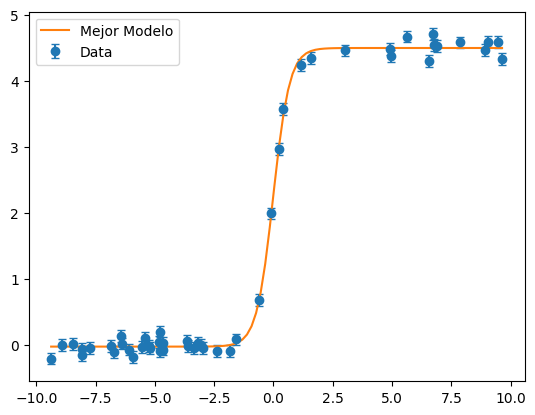

In [178]:
_x = np.linspace(min(x),max(x),100)
_y = sigmoide(_x,*p_cf)
plt.errorbar(x,y, yerr=sigma, fmt='o', capsize=3,label='Data')
plt.plot(_x,_y,label='Mejor Modelo')
plt.legend()

In [179]:
p_cf

array([ 4.69277439,  1.03801632,  2.8737759 , -0.02232699])

In [180]:
perr_cf

array([0.24778802, 0.05506813, 0.15973728, 0.01619329])